<a href="https://colab.research.google.com/github/yinsenf/fork_u-house_card/blob/main/colab_generator/generate_house_assets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
#@title 1. Setup & Configuration
#@markdown Enter your API Key and House Description below.

import os
import time
import zipfile
from pathlib import Path
from google.colab import files
from google.colab import userdata

# Install SDK
!pip install -q -U google-generativeai
import google.generativeai as genai

# Configuration
GOOGLE_API_KEY = "" #@param {type:"string"}
HOUSE_DESCRIPTION = "A single-story house with lower exterior walls clad in exposed red-brown brick covering the lower 40-50% of all front-facing walls, upper walls in cream/off-white stucco. Garage side wall is plain cream stucco with no brick.  The brick-to-stucco transition is at roughly window-sill height. Roof: dark red-brown Spanish S-shaped clay tiles with a weathered, aged patina. Color similar to burnt sienna or dark terracotta — NOT orange, NOT honey-toned. Consistent dark tone across all roof sections.  Small chimney visible  near the center ridge. Two distinct solar panel arrays on different roof sections. Multiple carefully placed windows and a clean white two-car garage door. Dense landscaping with foundational shrubs and garden beds along the house walls and the walkway. A gently curving walkway from the driveway to the front door, paved with concrete and bordered by red brick edging on both sides. A red Tesla Model Y 2026 Juniper parked on the concrete driveway. The car's front bumper and headlights face toward the street/viewer (away from the garage door). The car's rear is closest to the garage. Do not generate trees. All architectural and landscaping details are sharp, clean, and meticulously rendered with clear textures. The house and its immediate property must occupy at least 85-90% of the image frame, creating a compact, maximized presence. Follow the floor plan to generate the building" #@param {type:"string"}

# Model Selection
MODEL_TYPE = "gemini-2.5-flash-image" #@param ["gemini-3-pro-image-preview", "gemini-2.5-flash-image"]

if not GOOGLE_API_KEY:
    print("❌ Please enter your API Key!")
else:
    genai.configure(api_key=GOOGLE_API_KEY)
    print(f"✅ Configured with model: {MODEL_TYPE}")

# Directory Setup
BASE_DIR = Path("/content/house_assets")
REF_DIR = BASE_DIR / "reference"
OUT_DIR = BASE_DIR / "output"
MASTER_DIR = BASE_DIR / "master"

for d in [REF_DIR, OUT_DIR, MASTER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

✅ Configured with model: gemini-2.5-flash-image


In [62]:
#@title 2. Upload Reference Images
#@markdown Upload 1-5 photos of your house. Ideally: 1 front view, 1 side view, 1 isometric/satellite view if available.

CLEAR_PREVIOUS = False #@param {type:"boolean"}

if CLEAR_PREVIOUS:
    for f in REF_DIR.glob("*"):
        f.unlink()
    print("Cleared previous uploads.")

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, REF_DIR / filename)
    print(f"Saved reference: {filename}")

print(f"\nTotal references: {len(list(REF_DIR.glob('*')))}")


Saving road-side.jpg to road-side.jpg
Saved reference: road-side.jpg

Total references: 3


In [90]:
#@title 3. Define Prompts & Logic

# === MASTER PROMPT (full description, generates from scratch) ===

MASTER_RULES = """
RULES (CAMERA):
- VIEW: Strict isometric projection (SimCity / The Sims style). Parallel lines stay parallel. Never change the camera angle.
- Composition: Asset centered with generous padding on all sides. Entire glassmorphism base must be fully visible.
- ASPECT RATIO: 3:2.

RULES (VISUAL STYLE):
- Style: Ultra-high-fidelity 3D asset, "SimCity 2030" / "The Sims 5" aesthetic.
- Lighting: Dramatic, cinematic, high contrast. Intense golden hour sun shafts (day) or deep navy/cyan nocturnal tones (night).
- Effects: Volumetric God rays on the asset only, soft bloom, rich ray-traced reflections.
- Materiality: Hyper-realistic textures. The plot surface is a realistic lush green grass lawn with soil underneath. The entire plot sits on top of a thick glassmorphism base plate — the glass is only visible at the edges and bottom, NOT on the plot surface. The grass must fully cover the top of the base.
- Background: Solid #121212 for perfect cutout.
- Quality: 4K RAW, maximum sharpness, zero blur.

RULES (ARCHITECTURE):
- Description: {house_desc}
- ASPECT RATIO: 3:2.

CRITICAL INSTRUCTION:
You will be provided with reference images. Do NOT apply a filter or edit the reference.
Re-draw the scene from scratch for perfect sharpness and the requested 3D Asset Isometric style.
Use the references ONLY for geometry, angle, and architectural details. Do NOT watermark.
"""

# === VARIANT PROMPT (no architecture description, defers to master image) ===

VARIANT_RULES = """
RULES (CAMERA):
- VIEW: Strict isometric projection (SimCity / The Sims style). Parallel lines stay parallel. Never change the camera angle.
- Composition: Asset centered with generous padding on all sides. Entire glassmorphism base must be fully visible.
- ASPECT RATIO: 3:2.

RULES (VISUAL STYLE):
- Style: Ultra-high-fidelity 3D asset, "SimCity 2030" / "The Sims 5" aesthetic.
- Lighting: Dramatic, cinematic, high contrast.
- Effects: Volumetric God rays on the asset only, soft bloom, rich ray-traced reflections.
- Materiality: Hyper-realistic textures. The plot surface is a realistic lush green grass lawn with soil underneath. The entire plot sits on top of a thick glassmorphism base plate — the glass is only visible at the edges and bottom, NOT on the plot surface. The grass must fully cover the top of the base.
- Background: Solid #121212 for perfect cutout.
- Quality: 4K RAW, maximum sharpness, zero blur.

RULES (ARCHITECTURE):
- Replicate the provided master reference image EXACTLY for all architectural details: house geometry, wall materials, wall colors, roof tiles, windows, garage door, landscaping, walkway, driveway, and solar panels.
- Keep geometry, camera angle, and scale 100% identical to the master reference.
- Do NOT alter, add, or remove any architectural elements unless explicitly instructed below.

CRITICAL INSTRUCTION:
Re-draw the scene from scratch for perfect sharpness. Do NOT apply a filter on the reference.
Use the reference ONLY for geometry, materials, and architectural details. Do NOT watermark.
"""

WEATHER_RULES = {
    "sunny": "Cloudless sky. Plot highly illuminated by golden sun rays.",
    "partly_cloudy": "30-50% cloud coverage drifting across the sky. Soft cloud shadows on the plot. Sunlight breaks through gaps, creating alternating bright and shaded patches on the ground.",
    "overcast": "Fully overcast sky, flat diffused lighting with no direct sun. Muted desaturated colors across the entire plot. Soft even shadows, slightly blue-gray color cast on all surfaces.",
    "rainy": "Heavy rain: Draw a downpour in front of the house on the plot. Light reflections and wet surface sheen on driveway and walkway.",
    "lightning": "Thunderstorms: Draw strong lightning bolts in the sky. House strongly overexposed by lightning flashes.",
    "fog": "Fog: Draw fog, a delicate cloud or slight smoke in front of house and surroundings.",
}

VALID_COMBOS = {
    "winter":  ["sunny", "partly_cloudy", "overcast", "rainy", "lightning", "fog"],
    "spring":  ["sunny", "partly_cloudy", "overcast", "rainy", "lightning", "fog"],
    "summer":  ["sunny", "partly_cloudy"],
    "autumn":  ["sunny", "partly_cloudy", "overcast"],
}

SEASON_GROUND = {
    "winter": "Mild cool-tone atmosphere, lush green lawn (no snow), crisp clear lighting with slightly lower sun angle, cool white daylight color temperature",
    "spring": "Spring atmosphere, blooming flowers if applicable, vibrant saturated colors, fresh bright-green vegetation",
    "summer": "Summer atmosphere, bright harsh sunlight, dry golden-toned vegetation hints",
    "autumn": "Warm amber-orange color grading, slightly hazy atmosphere with reduced visibility, long golden shadows, dry warm-toned vegetation, golden hour warmth across all surfaces",
}

SEASONS = list(VALID_COMBOS.keys())
TIMES = ["day", "night"]

GAMING_MODES = {
    "mario": "Mario Bros World style: Green pipe, gold coins/stars on roof, beanstalk to sky. Mario & Luigi grilling meat in front of the house."
}


def get_base_prompt_for_master() -> str:
    return f"""Task: Create a "SimCity 2030" style 3D asset of the house.
{MASTER_RULES.format(house_desc=HOUSE_DESCRIPTION.strip())}
Specific for THIS image: Summer, Day, Sunny, bright.
"""


def get_prompt_for_variant(season, time_of_day, weather="sunny", tesla_present=True, extras="") -> str:
    if weather not in VALID_COMBOS.get(season, []):
        print(f"⚠️  Skipping invalid combo: {season}/{weather}")
        return None

    night_rule = "Apply night colors to plot. Lights on inside house. Illuminate driveway/path." if time_of_day == "night" else ""
    weather_desc = WEATHER_RULES.get(weather, "")
    ground_desc = SEASON_GROUND.get(season, "Summer atmosphere")

    if tesla_present:
        tesla_rule = "Keep the red Tesla Model Y on the driveway exactly as shown in the reference."
    else:
        tesla_rule = "REMOVE the car from the scene entirely. The concrete driveway must be completely empty and clean. No vehicle of any kind."

    return f"""Reference: Master Image. Same isometric angle, position, scale.
{VARIANT_RULES}
VEHICLE: {tesla_rule}

Specific for THIS request:
- Season: {season.capitalize()}
- Time: {time_of_day.capitalize()}
- Weather: {weather_desc}
- Atmosphere/Ground: {ground_desc}
{night_rule}
{extras}
"""


def _build_filename(season, time_of_day, weather, tesla_present):
    """Build filename: sunny is omitted, tesla is suffix.
    Format: {season}_{weather}_{time}_{tesla}.png
    Examples: winter_day.png, winter_fog_night.png,
              winter_day_tesla.png, winter_fog_night_tesla.png
    """
    parts = [season]
    if weather != "sunny":
        parts.append(weather)
    parts.append(time_of_day)
    if tesla_present:
        parts.append("tesla")
    return "_".join(parts) + ".png"


def get_all_variants():
    """Generate list of all valid (season, time, weather, tesla) combos."""
    variants = []
    for season, weathers in VALID_COMBOS.items():
        for weather in weathers:
            for time_of_day in TIMES:
                for tesla in [False, True]:
                    variants.append({
                        "season": season,
                        "time": time_of_day,
                        "weather": weather,
                        "tesla_present": tesla,
                        "filename": _build_filename(season, time_of_day, weather, tesla),
                    })
    return variants


def generate_image(prompt, ref_images, output_path):
    if prompt is None:
        return False
    print(f"Generating {output_path.name}...")
    model = genai.GenerativeModel(MODEL_TYPE)
    contents = [prompt]

    for p in ref_images:
        if p.exists():
            from PIL import Image
            contents.append(Image.open(p))

    try:
        response = model.generate_content(contents)
        if response.candidates and response.candidates[0].content.parts:
            for part in response.candidates[0].content.parts:
                if hasattr(part, "inline_data") and part.inline_data:
                    from PIL import Image
                    import io
                    img = Image.open(io.BytesIO(part.inline_data.data))
                    img.save(output_path, "PNG")
                    return True
        print("No image generated.")
        return False
    except Exception as e:
        print(f"Error: {e}")
        if "429" in str(e):
            print("Rate limit hit. Waiting 60s...")
            time.sleep(60)
        return False


# Print summary
all_variants = get_all_variants()
combo_count = sum(len(v) for v in VALID_COMBOS.values())
print(f"✅ Prompts loaded.")
print(f"   Valid season/weather combos: {combo_count}")
print(f"   x day/night = {combo_count * 2}")
print(f"   x tesla y/n = {len(all_variants)}")
print(f"   + 1 master  = {len(all_variants) + 1} total images")
print(f"\nSample filenames:")
for v in all_variants[:6]:
    print(f"   {v['filename']}")
print(f"   ...")

✅ Prompts loaded.
   Valid season/weather combos: 17
   x day/night = 34
   x tesla y/n = 68
   + 1 master  = 69 total images

Sample filenames:
   winter_day.png
   winter_day_tesla.png
   winter_night.png
   winter_night_tesla.png
   winter_partly_cloudy_day.png
   winter_partly_cloudy_day_tesla.png
   ...


Generating _master_reference.png...
✅ Master Generated:


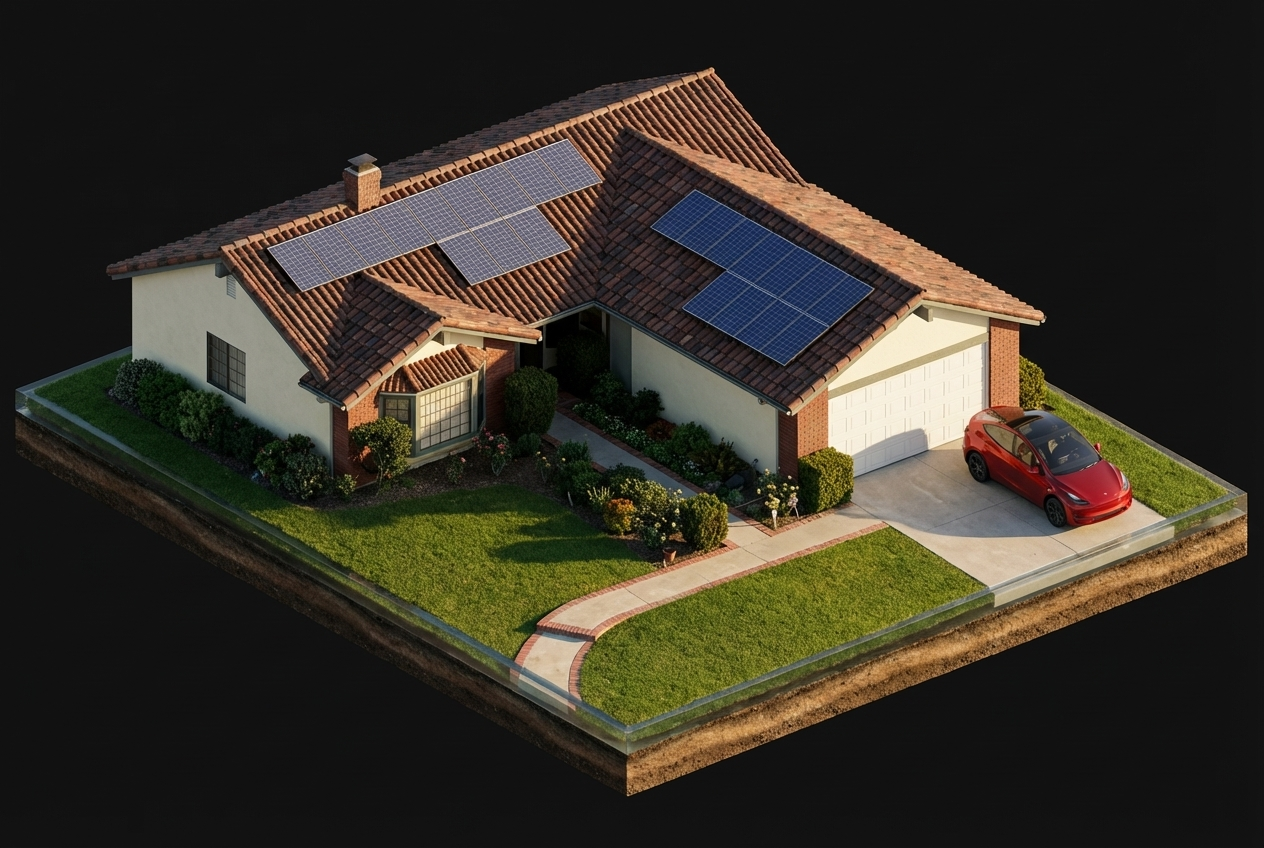

In [82]:
#@title 4. Generate Master Reference
#@markdown This generates the base "Summer Day" image. Verify it before proceeding!

master_path = MASTER_DIR / "_master_reference.png"
refs = list(REF_DIR.glob("*"))

success = generate_image(
    get_base_prompt_for_master(),
    refs,
    master_path
)

if success:
    from IPython.display import Image, display
    print("✅ Master Generated:")
    display(Image(filename=str(master_path), width=400))
else:
    print("❌ Master generation failed. Check your API key or Try again.")

Saving _master_reference.png to _master_reference.png
Master saved: /content/house_assets/master/_master_reference.png
Size: 1264x848


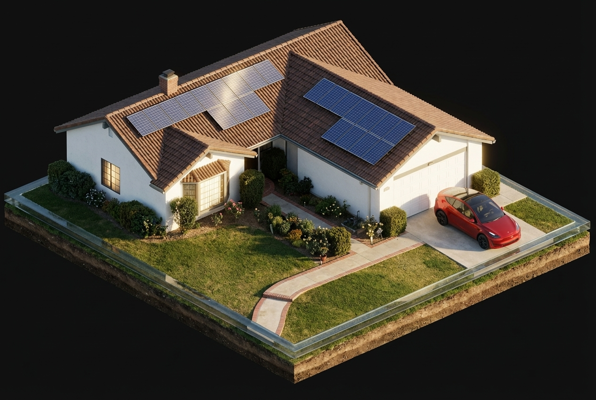

In [76]:
#@title 4b. (Optional) Upload Existing Master Image
#@markdown Skip step 4 if you already have a master image you're happy with. Upload it here and it will be used as the reference for all variants.

REPLACE_EXISTING_MASTER = True #@param {type:"boolean"}

master_path = MASTER_DIR / "_master_reference.png"

if master_path.exists() and not REPLACE_EXISTING_MASTER:
    print(f"Master already exists: {master_path}")
    print("Set REPLACE_EXISTING_MASTER = True to overwrite.")
else:
    uploaded = files.upload()

    if uploaded:
        filename = list(uploaded.keys())[0]

        from PIL import Image
        img = Image.open(filename)
        img.save(master_path, "PNG")
        os.remove(filename)

        print(f"Master saved: {master_path}")
        print(f"Size: {img.size[0]}x{img.size[1]}")

        # Display preview
        from IPython.display import display
        img.thumbnail((600, 400))
        display(img)
    else:
        print("No file uploaded.")

In [93]:
#@title 5. Generate All Variants
#@markdown Loops through all valid season/time/weather/tesla combos. This may take a while.

master_path = MASTER_DIR / "_master_reference.png"
if not master_path.exists():
    print("No Master image found. Run step 4 or 4b first.")
else:
    all_variants = get_all_variants()
    total = len(all_variants)
    done = 0
    skipped = 0
    failed = 0

    for v in all_variants:
        out_path = OUT_DIR / v["filename"]
        if out_path.exists():
            skipped += 1
            continue

        prompt = get_prompt_for_variant(
            season=v["season"],
            time_of_day=v["time"],
            weather=v["weather"],
            tesla_present=v["tesla_present"],
        )
        success = generate_image(prompt, [master_path], out_path)
        if success:
            done += 1
        else:
            failed += 1
        print(f"  [{done + skipped + failed}/{total}] {v['filename']} - {'ok' if success else 'FAILED'}")

    print(f"\nGeneration complete: {done} generated, {skipped} existed, {failed} failed, {total} total.")

    # Xmas variants
    xmas_configs = [
        ("day",   False, "Santa sliding down roof, penguins, igloo, festive decorations."),
        ("day",   True,  "Santa sliding down roof, penguins, igloo, festive decorations."),
        ("night", False, "Santa sliding down roof, penguins, igloo, festive decorations, glowing lights."),
        ("night", True,  "Santa sliding down roof, penguins, igloo, festive decorations, glowing lights."),
    ]
    for t, tesla, extras in xmas_configs:
        fname = _build_filename("winter_xmas", t, "sunny", tesla)
        if not (OUT_DIR / fname).exists():
            prompt = get_prompt_for_variant("winter", t, "sunny", tesla_present=tesla, extras=extras)
            generate_image(prompt, [master_path], OUT_DIR / fname)
            print(f"  Xmas: {fname}")

    # Gaming modes
    for mode, desc in GAMING_MODES.items():
        fname = f"gaming_{mode}.png"
        if not (OUT_DIR / fname).exists():
            prompt = get_prompt_for_variant("summer", "day", "sunny", tesla_present=True, extras=desc)
            generate_image(prompt, [master_path], OUT_DIR / fname)
            print(f"  Gaming: {fname}")

    print("\nAll done.")

Generating winter_day.png...


KeyboardInterrupt: 

Generating: spring_day_tesla.png
Generating spring_day_tesla.png...
Saved: /content/house_assets/output/spring_day_tesla.png


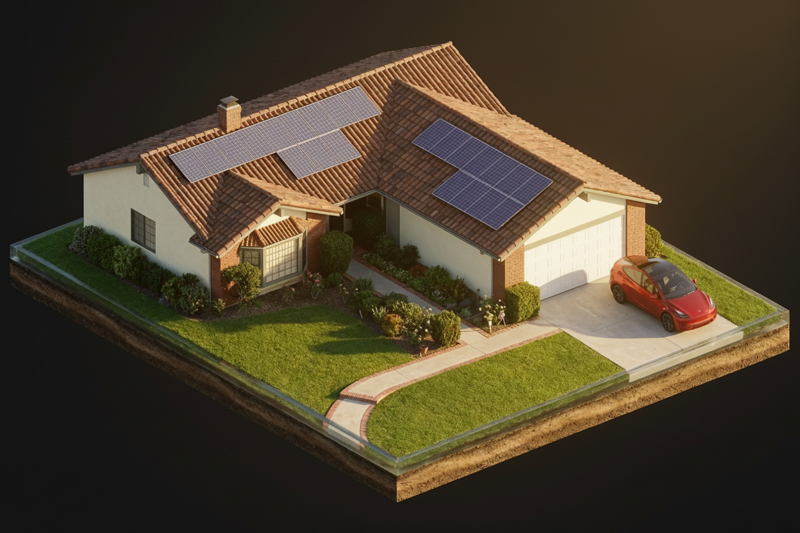

In [92]:
#@title 5b. Generate Single Image
#@markdown Select options and generate one image at a time.

SEASON = "spring" #@param ["winter", "spring", "summer", "autumn"]
TIME_OF_DAY = "day" #@param ["day", "night"]
WEATHER = "sunny" #@param ["sunny", "partly_cloudy", "overcast", "rainy", "lightning", "fog"]
TESLA = True #@param {type:"boolean"}
EXTRAS = "" #@param {type:"string"}

master_path = MASTER_DIR / "_master_reference.png"
if not master_path.exists():
    print("No Master image found. Run step 4 or 4b first.")
else:
    # Validate combo
    if WEATHER not in VALID_COMBOS.get(SEASON, []):
        print(f"Invalid combo: {SEASON} + {WEATHER}")
        print(f"Valid weather for {SEASON}: {VALID_COMBOS[SEASON]}")
    else:
        filename = _build_filename(SEASON, TIME_OF_DAY, WEATHER, TESLA)
        out_path = OUT_DIR / filename

        prompt = get_prompt_for_variant(
            season=SEASON,
            time_of_day=TIME_OF_DAY,
            weather=WEATHER,
            tesla_present=TESLA,
            extras=EXTRAS,
        )

        print(f"Generating: {filename}")
        success = generate_image(prompt, [master_path], out_path)

        if success:
            print(f"Saved: {out_path}")
            from IPython.display import display
            from PIL import Image
            img = Image.open(out_path)
            img.thumbnail((800, 600))
            display(img)
        else:
            print("Generation failed. Try again.")

In [85]:
#@title 6. Download Results
#@markdown Zips all generated images and triggers download.

zip_path = BASE_DIR / "house_assets.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in OUT_DIR.glob("*.png"):
        zipf.write(file, file.name)
    # Add Master too
    if master_path.exists():
        zipf.write(master_path, "_master_reference.png")

print(f"Zipped {len(list(OUT_DIR.glob('*.png')))} files.")
files.download(str(zip_path))

Zipped 109 files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>